<a href="https://colab.research.google.com/github/BaraArdiwinata/ATTD-Pipeline-Orchestration-IndoBERT/blob/main/scripts/ESG_Greenwashing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESG Greenwashing Detection — Data Wrangling & Visualization
**Proyek:** Analisis Sentimen ESG berbasis IndoBERT untuk Deteksi Greenwashing  
**Output:** Siap dimasukkan ke Bab 4 Proposal Riset

## 0. Setup & Import Library

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import re
from collections import Counter
import warnings
import os

warnings.filterwarnings('ignore')

# Konfigurasi tampilan global
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})
sns.set_palette('muted')

# Folder output
OUTPUT_DIR = 'data/models/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Library siap. Output disimpan ke:', os.path.abspath(OUTPUT_DIR))

✅ Library siap. Output disimpan ke: /content/data/models


## 1. Load Data
Mengambil data dari GitHub repository `BaraArdiwinata/ATTD-Pipeline-Orchestration-IndoBERT`.

In [77]:
BASE_URL = 'https://raw.githubusercontent.com/BaraArdiwinata/ATTD-Pipeline-Orchestration-IndoBERT/main/'

URL_INDOBERT   = BASE_URL + 'data/IndoBERT.csv'
URL_PRED       = BASE_URL + 'data/models/test_predictions.csv'

# Try to load IndoBERT.csv from GitHub, fallback to local if needed
try:
    df_ner  = pd.read_csv(URL_INDOBERT)
    print(f'✅ IndoBERT.csv (remote)     : {df_ner.shape[0]:,} baris, {df_ner.shape[1]} kolom')
except Exception as e:
    print(f'⚠️  Gagal ambil IndoBERT.csv dari GitHub: {e}')
    print('   → Fallback ke IndoBERT.csv lokal...')
    try:
        df_ner  = pd.read_csv('data/IndoBERT.csv')
        print(f'✅ IndoBERT.csv (lokal)      : {df_ner.shape[0]:,} baris, {df_ner.shape[1]} kolom')
    except Exception as e_local:
        print(f'❌ Gagal ambil IndoBERT.csv dari lokal juga: {e_local}')
        raise # Re-raise if both failed

# Try to load test_predictions.csv from GitHub, fallback to local if needed
try:
    df_pred = pd.read_csv(URL_PRED)
    print(f'✅ test_predictions (remote) : {df_pred.shape[0]:,} baris, {df_pred.shape[1]} kolom')
except Exception as e:
    print(f'⚠️  Gagal ambil test_predictions dari GitHub: {e}')
    print('   → Fallback ke test_predictions lokal...')
    try:
        df_pred = pd.read_csv('data/models/test_predictions.csv')
        print(f'✅ test_predictions (lokal)  : {df_pred.shape[0]:,} baris, {df_pred.shape[1]} kolom')
    except Exception as e_local:
        print(f'❌ Gagal ambil test_predictions dari lokal juga: {e_local}')
        raise # Re-raise if both failed

✅ IndoBERT.csv (remote)     : 468 baris, 29 kolom
✅ test_predictions (remote) : 94 baris, 35 kolom


In [78]:
# Preview kolom kunci
print('=== Kolom IndoBERT.csv ===')
print(df_ner.columns.tolist())
print('\n=== Kolom test_predictions.csv ===')
print(df_pred.columns.tolist())

=== Kolom IndoBERT.csv ===
['Link', 'Sentiment', 'Penerbit', 'Tag', 'Perusahaan', 'Tahun', 'Isi Berita Clean', '_tgl_url', '_tgl_teks', 'tanggal', 'sumber_tanggal', 'bulan', 'quarter', 'tahun_fix', 'clean_text', 'tokens', 'jumlah_token', 'panjang_kata', 'Teks_English', 'Sentiment_TextBlob', 'InSet_Score', 'Sentiment_InSet', 'pos_indobert', 'pos_finetuned', 'IndoBERT_ORG', 'IndoBERT_LOC', 'IndoBERT_ORG_Baru', 'IndoBERT_LOC_Baru', 'IndoBERT_GPE_Baru']

=== Kolom test_predictions.csv ===
['Link', 'Sentiment', 'Penerbit', 'Tag', 'Perusahaan', 'Tahun', 'Isi Berita Clean', '_tgl_url', '_tgl_teks', 'tanggal', 'sumber_tanggal', 'bulan', 'quarter', 'tahun_fix', 'clean_text', 'tokens', 'jumlah_token', 'panjang_kata', 'Teks_English', 'Sentiment_TextBlob', 'InSet_Score', 'Sentiment_InSet', 'pos_indobert', 'pos_finetuned', 'IndoBERT_ORG', 'IndoBERT_LOC', 'IndoBERT_ORG_Baru', 'IndoBERT_LOC_Baru', 'IndoBERT_GPE_Baru', 'label_sent', 'label_tag', 'pred_sentiment', 'pred_tag', 'correct_sentiment', 'corr

## 2. Merge Dataset
Gabungkan berdasarkan kolom `Link` (identifier artikel) sebagai key utama.  
Fallback: merge by index jika `Link` tidak tersedia di kedua dataframe.

In [79]:
# Kolom yang dibutuhkan dari masing-masing sumber
COLS_NER  = ['Link', 'Penerbit', 'pos_indobert', 'Sentiment']
COLS_PRED = ['Link', 'IndoBERT_ORG', 'pred_sentiment']

# Pilih kolom yang benar-benar ada
cols_ner_avail  = [c for c in COLS_NER  if c in df_ner.columns]
cols_pred_avail = [c for c in COLS_PRED if c in df_pred.columns]

df_left  = df_ner[cols_ner_avail].copy()
df_right = df_pred[cols_pred_avail].copy()

# Jika pos_indobert ada di df_pred, ambil dari sana
if 'pos_indobert' not in df_left.columns and 'pos_indobert' in df_pred.columns:
    df_right['pos_indobert'] = df_pred['pos_indobert']

# Merge via Link; fallback via index
if 'Link' in df_left.columns and 'Link' in df_right.columns:
    df = pd.merge(df_left, df_right, on='Link', how='left') # Ubah inner jadi left
    print(f'✅ Merge via Link → {df.shape[0]:,} baris')
else:
    # Fallback: merge berdasarkan urutan index
    n = min(len(df_left), len(df_right))
    df = pd.concat([df_left.iloc[:n].reset_index(drop=True),
                    df_right.iloc[:n].reset_index(drop=True)], axis=1)
    df = df.loc[:, ~df.columns.duplicated()]
    print(f'✅ Merge via index → {df.shape[0]:,} baris')

# Pastikan kolom wajib ada
for col in ['Penerbit', 'IndoBERT_ORG', 'pred_sentiment', 'pos_indobert', 'Sentiment']:
    if col not in df.columns:
        raise KeyError(f'Kolom wajib tidak ditemukan setelah merge: {col}')

print(f'✅ Dataset gabungan: {df.shape}')
df.head(2)

✅ Merge via Link → 474 baris
✅ Dataset gabungan: (474, 6)


,Link,Penerbit,pos_indobert,Sentiment,IndoBERT_ORG,pred_sentiment
0,https://www.straitstimes.com/business/palm-oil...,Straitstimes.com,"[('choose', 'B-NNP'), ('edition', 'B-NNP'), ('...",Netral,"##eds, bumitama agri, ##ion, visual, ##ama, as...",Netral
1,https://www.tempo.co/lingkungan/walhi-ungkap-d...,tempo,"[('wahana', 'B-NNO'), ('lingkung', 'B-NNP'), (...",Negatif,NaN,NaN


---
## Step 1 — Media Grouping & Sentiment Mapping
> **Untuk Bab 4.2** — Kategorisasi Media & Pemetaan Sentimen Numerik

In [80]:
# ─── Untuk Bab 4.2 ──────────────────────────────────────────────────────────

# Daftar media investigatif
INVESTIGATIF = ['Project Multatuli', 'Mongabay', 'BBC', 'WALHI', 'Tempo']

# Kolom Kategori Media
df['Kategori_Media'] = df['Penerbit'].apply(
    lambda x: 'Investigatif' if str(x).strip() in INVESTIGATIF else 'Umum'
)

# Mapping sentimen ke numerik
SKOR_MAP = {'Positif': 1, 'Netral': 0, 'Negatif': -1}

# Ambil dari pred_sentiment, kalau kosong isi pakai Sentiment asli korpus
df['Sentiment_Final'] = df['pred_sentiment'].fillna(df['Sentiment'])
df['Skor_Sentimen'] = df['Sentiment_Final'].map(SKOR_MAP)

print('Distribusi Kategori Media:')
print(df['Kategori_Media'].value_counts())
print('\nDistribusi Sentimen:')
print(df['pred_sentiment'].value_counts())
print('\nSample NaN di Skor_Sentimen:', df['Skor_Sentimen'].isna().sum())

Distribusi Kategori Media:
Kategori_Media
Umum            370
Investigatif    104
Name: count, dtype: int64

Distribusi Sentimen:
pred_sentiment
Negatif    64
Positif    33
Netral     24
Name: count, dtype: int64

Sample NaN di Skor_Sentimen: 0


---
## Step 2 — NER Explode & SDS Calculation
> **Untuk Bab 4.3** — Kalkulasi Sentiment Discrepancy Score (SDS) per Perusahaan

In [81]:
# ─── Untuk Bab 4.3 ──────────────────────────────────────────────────────────

def parse_org_list(val):
    """Parse kolom IndoBERT_ORG: bisa berupa string list Python atau CSV."""
    if pd.isna(val):
        return []
    val = str(val).strip()
    # Coba parse sebagai Python list
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [str(x).strip().lower() for x in parsed if str(x).strip()]
    except Exception:
        pass
    # Fallback: split by koma
    return [x.strip().lower() for x in val.split(',') if x.strip()]


# Kolom kerja untuk explode
df_work = df[['Kategori_Media', 'Skor_Sentimen', 'IndoBERT_ORG']].copy()
df_work['ORG_List'] = df_work['IndoBERT_ORG'].apply(parse_org_list)

# Explode: satu baris = satu entitas organisasi
df_exploded = df_work.explode('ORG_List').rename(columns={'ORG_List': 'Entitas'})
df_exploded = df_exploded.dropna(subset=['Entitas', 'Skor_Sentimen'])
df_exploded = df_exploded[df_exploded['Entitas'] != '']

print(f'✅ Jumlah baris setelah explode: {len(df_exploded):,}')
df_exploded.head(40)

✅ Jumlah baris setelah explode: 557


,Kategori_Media,Skor_Sentimen,IndoBERT_ORG,Entitas
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",##eds
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",bumitama agri
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",##ion
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",visual
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",##ama
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",asia world opinion
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",productiv
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",##d sept
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",up
0,Umum,0,"##eds, bumitama agri, ##ion, visual, ##ama, as...",##i


⏳ 1. Mereset dan melakukan explode dataset...
⏳ 2. Menjalankan Keyword-Based Mapping (Konsolidasi Perusahaan)...
⏳ 3. Menyaring aktor non-korporat dan membatasi jumlah kata...
✅ Jumlah baris valid pasca-pembersihan komprehensif: 332
⏳ 4. Menghitung akumulasi nilai matematika SDS...
✅ Perusahaan lolos threshold (n≥2) di kedua kubu media: 3

📊 HASIL FINAL TABEL DISKREPANSI SENTIMEN (PROXSI GREENWASHING):

✅ TABLE 1 (SDS Greenwashing Result) disimpan: data/models/SDS_Greenwashing_Result.csv


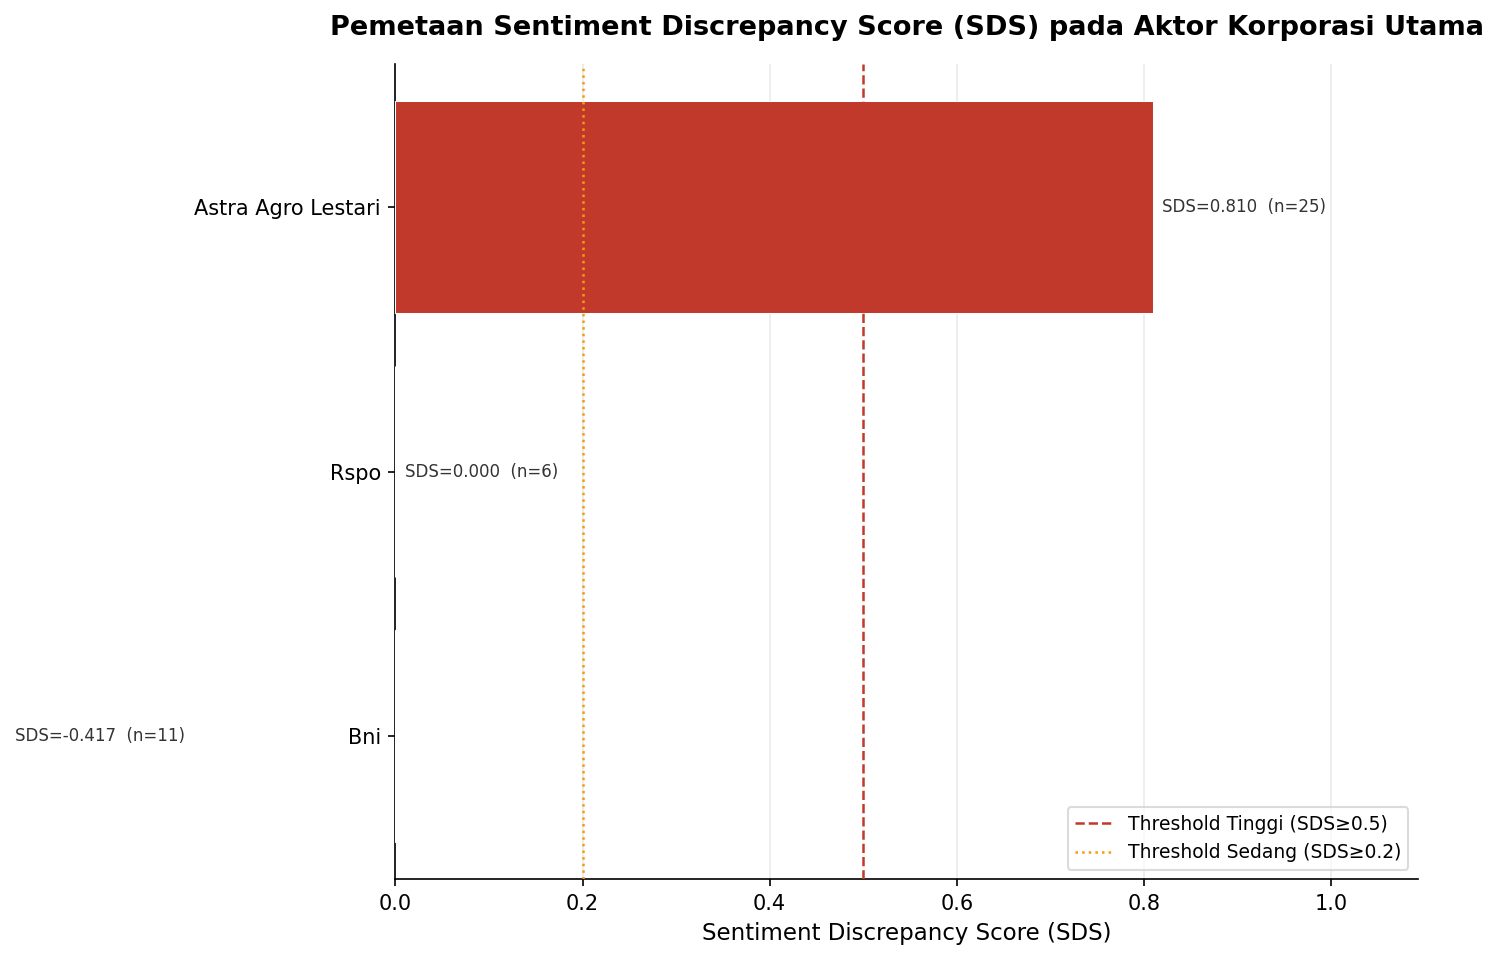


✅ VISUAL 2 (Top 10 SDS Greenwashing) disimpan: data/models/top_10_sds_greenwashing.png


In [88]:
# ============================================================================
# ⚒️ REVISI FINAL STEP 2: KONSOLIDASI ENTITAS & KALKULASI SDS (ANTI-NOISE)
# ============================================================================

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("⏳ 1. Mereset dan melakukan explode dataset...")
# Ambil ulang data segar langsung dari df utama untuk menghindari error potong huruf sebelumnya
df_work = df[['Kategori_Media', 'Skor_Sentimen', 'IndoBERT_ORG']].copy()

def safe_parse_org(val):
    if pd.isna(val):
        return []
    try:
        # Jika format berupa string representasi list, misal: "['AAL', 'RSPO']"
        return ast.literal_eval(val)
    except:
        # Fallback jika string biasa dipisahkan tanda koma
        return [item.strip() for item in str(val).replace('[','').replace(']','').replace("'",'').split(',') if item.strip()]

df_work['ORG_Clean_List'] = df_work['IndoBERT_ORG'].apply(safe_parse_org)

# Jalankan Explode: Memecah list menjadi satu baris demi satu perusahaan
df_exploded = df_work.explode('ORG_Clean_List').rename(columns={'ORG_Clean_List': 'Entitas'})
df_exploded = df_exploded.dropna(subset=['Entitas', 'Skor_Sentimen'])

# Bersihkan subword token '##' dan ubah ke lowercase untuk standardisasi pembersihan
df_exploded['Entitas'] = df_exploded['Entitas'].astype(str).str.lower().str.replace('##', '', regex=False).str.strip()
df_exploded = df_exploded[df_exploded['Entitas'] != ''].copy()


print("⏳ 2. Menjalankan Keyword-Based Mapping (Konsolidasi Perusahaan)...")
# ATURAN 1: Menyatukan berbagai variasi nama compang-camping menjadi satu nama resmi
def konsolidasi_nama(teks):
    if 'astra' in teks or 'aal' in teks:
        return 'Astra Agro Lestari'
    elif 'bni' in teks:
        return 'BNI'
    elif 'bri' in teks: # BNI already covers it, but kept for clarity
        return 'BRI'
    elif 'rspo' in teks:
        return 'RSPO'
    return teks

df_exploded['Entitas'] = df_exploded['Entitas'].apply(konsolidasi_nama)


print("⏳ 3. Menyaring aktor non-korporat dan membatasi jumlah kata...")
# ATURAN 3: Blacklist kata kunci untuk menyingkirkan gerakan sipil/LSM (Partial Matching)
NON_CORPORATE_KEYWORDS = [
    'masyarakat', 'sipil', 'organisasi', 'koalisi', 'tuntut', 'desak', 'bantu',
    'hukum', 'ylbhi', 'lembaga', 'pemerintah', 'warga', 'nasional', 'menteri',
    'direktur', 'who', 'pangan', 'riset', 'brin', 'gapki', 'indonesia', 'mobil',
    'pasal', 'utara', 'kelanjutan', 'industri', 'kementerian', 'dewan', 'undang',
    'hing', 'usaha', 'badan', 'keberlanjutan', 'industri', 'tahan', 'sawit ber', 'sipil', 'desak' # Added new fragment words
]

def filter_non_korporasi(teks):
    # Jika sudah dikonsolidasi ke nama korporat resmi, jangan dibuang
    if teks in ['Astra Agro Lestari', 'BNI', 'BRI', 'RSPO']:
        return True

    # Cek jika teks mengandung kata kunci sampah non-korporasi
    for word in NON_CORPORATE_KEYWORDS:
        if word in teks:
            return False
    return True

df_exploded = df_exploded[df_exploded['Entitas'].apply(filter_non_korporasi)].copy()

# ATURAN 2: Batasi panjang kata (maksimal 4 kata) & panjang karakter (>2 karakter)
df_exploded = df_exploded[df_exploded['Entitas'].str.split().str.len() <= 4].copy()
df_exploded = df_exploded[df_exploded['Entitas'].str.len() > 2].copy()


# Define the blacklist for common words that are not useful as organizations
# This list should be defined *after* initial parsing and lowercasing in safe_parse_org
BLACKLIST_ORG = [
    'indonesia', 'mobil', 'pasal', 'pemerintah', 'warga', 'nasional', 'masyarakat',
    'utara',
    'hing usaha kelapa sawit', # Added for removal based on previous output
    'kelanjutan', # Added for removal based on previous output
    'raksasa minyak sawit indonesia astra agro lestari washington jakarta amsterdam' # Exact full string for removal
]

# Define specific replacements for problematic long entities (all lowercase for consistency)
# Keys should be the exact lowercase strings as they appear after parse_org_list and initial cleaning
ENTITY_REPLACEMENTS = {
    # These will be mapped to '' and implicitly removed by subsequent filter
    'badan keberlanjutan industri kelapa sawit tahan': '',
    'organisasi sorot langgar lingkung hak asasi manusia tata kelola aal tuntut rspo': '', # Exact full string from previous output
    'masyarakat sipil desak rspo': '',
    'masyarakat sipil tuntut badan minyak sawit ber': '', # Original shortened version
    'masyarakat sipil tuntut badan minyak sawit ber...': '', # Adjusted for ellipsis variation
    'masyarakat sipil internasional': '',

    # These will be mapped to cleaner company names
    'astra agro lestari aal usaha kelapa sawit besar indonesia aal umum aju': 'astra agro lestari', # Exact full string from previous output
    'rspo umum': 'rspo',
    'aal': 'astra agro lestari' # General shorthand for Astra Agro Lestari
}

# Add words from ENTITY_REPLACEMENTS that are mapped to '' into BLACKLIST_ORG
# This ensures they are removed if they appear in other contexts as well, and handled by the blacklist filter
for k, v in ENTITY_REPLACEMENTS.items():
    if v == '':
        BLACKLIST_ORG.append(k)

# Ensure BLACKLIST_ORG has unique values and is all lowercase for robust comparison
BLACKLIST_ORG = list(set([item.lower() for item in BLACKLIST_ORG]))

# --- NEW: Re-introduce the exact blacklist filter ---
df_exploded = df_exploded[~df_exploded['Entitas'].isin(BLACKLIST_ORG)].copy()
# --- END NEW ---

# Format kata umum sisa lainnya yang lolos seleksi menjadi Title Case agar estetik
def final_formatting(teks):
    if teks in ['Astra Agro Lestari', 'BNI', 'BRI', 'RSPO']:
        return teks
    return teks.title()

df_exploded['Entitas'] = df_exploded['Entitas'].apply(final_formatting)

print(f'✅ Jumlah baris valid pasca-pembersihan komprehensif: {len(df_exploded):,}')


print("⏳ 4. Menghitung akumulasi nilai matematika SDS...")
# Hitung frekuensi kemunculan agregat total
freq_total = df_exploded.groupby('Entitas').size().rename('Frekuensi')

# Hitung rata-rata skor sentimen per perusahaan per jenis media
df_grouped = (
    df_exploded
    .groupby(['Entitas', 'Kategori_Media'])['Skor_Sentimen']
    .mean()
    .reset_index()
)

# Pivot kolom agar kategori Umum dan Investigatif berjejer horizontal
df_pivot = df_grouped.pivot(index='Entitas', columns='Kategori_Media', values='Skor_Sentimen')
df_pivot.columns.name = None
df_pivot = df_pivot.reset_index()

# Pastikan kedua kolom kategori media tersedia di dataframe
for col in ['Umum', 'Investigatif']:
    if col not in df_pivot.columns:
        df_pivot[col] = np.nan

# Gabungkan metrik frekuensi kemunculan berita
df_pivot = df_pivot.join(freq_total, on='Entitas')

# Batas minimum artikel (Threshold) diatur n>=2 agar variasi data PKM muncul
N_MIN = 2
df_pivot = df_pivot[df_pivot['Frekuensi'] >= N_MIN].copy()

# Eksekusi Rumus Sentiment Discrepancy Score (SDS)
df_pivot['SDS'] = df_pivot['Umum'] - df_pivot['Investigatif']
df_pivot = df_pivot.dropna(subset=['SDS'])  # Eliminasi perusahaan yang tidak punya irisan liputan dua media
df_pivot = df_pivot.sort_values('SDS', ascending=False).reset_index(drop=True)

# Penamaan ulang kolom output final demi keselarasan visual Bab 4
df_pivot = df_pivot.rename(columns={
    'Entitas': 'Perusahaan',
    'Umum': 'Mean_Sentimen_Umum',
    'Investigatif': 'Mean_Sentimen_Investigatif'
})

print(f'✅ Perusahaan lolos threshold (n≥{N_MIN}) di kedua kubu media: {len(df_pivot)}')
print('\n📊 HASIL FINAL TABEL DISKREPANSI SENTIMEN (PROXSI GREENWASHING):')
df_pivot.head(10)

# --- AUTO-SAVE OUTPUT (Previously in zTDw1SfZaetZ) ---

# For Bab 4.3 — TABLE 1
# OUTPUT_DIR is assumed to be defined in sHYB6pDIaetT

df_sds_export = df_pivot[['Perusahaan', 'Mean_Sentimen_Umum',
                           'Mean_Sentimen_Investigatif', 'SDS', 'Frekuensi']].copy()
df_sds_export['Perusahaan'] = df_sds_export['Perusahaan'].str.title()
df_sds_export = df_sds_export.round(4)

SAVE_T1 = os.path.join(OUTPUT_DIR, 'SDS_Greenwashing_Result.csv')
df_sds_export.to_csv(SAVE_T1, index=False, encoding='utf-8-sig')
print(f'\n✅ TABLE 1 (SDS Greenwashing Result) disimpan: {SAVE_T1}')


# --- AUTO-VISUALIZE TOP 10 SDS (Previously in mFBiU3WDaetY) ---

# For Bab 4.3 — VISUAL 2

TOP10 = df_pivot.head(10).copy()
TOP10['Label'] = TOP10['Perusahaan'].str.title()

# Warna: merah untuk SDS ≥ 0.5 (anomali kuat), kuning untuk SDS antara 0.2–0.5
def sds_color(val):
    if val >= 0.5:
        return '#C0392B'   # merah
    elif val >= 0.2:
        return '#F39C12'   # kuning/oranye
    else:
        return '#2980B9'   # biru normal

colors = TOP10['SDS'].apply(sds_color).tolist()

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(TOP10['Label'][::-1], TOP10['SDS'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5, zorder=3)

# Anotasi nilai SDS & frekuensi
for bar, (_, row) in zip(bars, TOP10[::-1].iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'SDS={row["SDS"]:.3f}  (n={int(row["Frekuensi"])})',
            va='center', ha='left', fontsize=8, color='#333')

# Garis threshold
ax.axvline(0.5, color='#C0392B', linestyle='--', linewidth=1.2,
           label='Threshold Tinggi (SDS≥0.5)', zorder=4)
ax.axvline(0.2, color='#F39C12', linestyle=':', linewidth=1.2,
           label='Threshold Sedang (SDS≥0.2)', zorder=4)

ax.set_xlabel('Sentiment Discrepancy Score (SDS)', fontsize=11)
ax.set_title('Pemetaan Sentiment Discrepancy Score (SDS) pada Aktor Korporasi Utama',
             fontsize=13, fontweight='bold', pad=14)
ax.legend(fontsize=9, framealpha=0.7, loc='lower right')
ax.set_xlim(0, TOP10['SDS'].max() * 1.35)
ax.grid(axis='x', alpha=0.25, zorder=0)

plt.tight_layout()
SAVE_V2 = os.path.join(OUTPUT_DIR, 'top_10_sds_greenwashing.png')
plt.savefig(SAVE_V2, dpi=180, bbox_inches='tight')
plt.show()
print(f'\n✅ VISUAL 2 (Top 10 SDS Greenwashing) disimpan: {SAVE_V2}')

In [83]:
print(df_pivot.to_string())

           Perusahaan  Mean_Sentimen_Investigatif  Mean_Sentimen_Umum  Frekuensi       SDS
0  Astra Agro Lestari                       -1.00           -0.190476         25  0.809524
1                RSPO                       -1.00           -1.000000          6  0.000000
2                 BNI                        0.75            0.333333         11 -0.416667


---
## Step 3 — Ekstraksi Puffery Words (Adjektiva Linguistik)
> **Untuk Bab 4.4** — Analisis Kata Klaim Berlebihan pada Media Umum

In [84]:
# ─── Untuk Bab 4.4 ──────────────────────────────────────────────────────────

def parse_pos_tags(val):
    """
    Parse kolom pos_indobert yang berisi list of tuples (kata, TAG).
    Mengembalikan list tuple; TAG 'B-ADJ' → Adjective.
    """
    if pd.isna(val):
        return []
    val = str(val).strip()
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return parsed
    except Exception:
        pass
    # Fallback: regex cari pola ('kata', 'TAG')
    pattern = r"\('([^']+)',\s*'([^']+)'\)"
    return re.findall(pattern, val)


def extract_adjectives(pos_list):
    """Ekstrak kata berkelas Adjective (tag mengandung ADJ)."""
    adj_tags = {'B-ADJ', 'I-ADJ', 'ADJ'}
    adjectives = []
    for item in pos_list:
        if isinstance(item, (list, tuple)) and len(item) == 2:
            word, tag = item[0], item[1]
            if tag in adj_tags or 'ADJ' in str(tag).upper():
                word_clean = str(word).strip().lower()
                # Filter noise: hanya kata alfanumerik minimal 3 char
                if len(word_clean) >= 3 and re.match(r'^[a-z]+$', word_clean):
                    adjectives.append(word_clean)
    return adjectives


# 5 perusahaan SDS tertinggi
TOP5 = df_pivot.head(5)['Perusahaan'].tolist()
print('Top 5 Perusahaan (SDS tertinggi):')
for i, p in enumerate(TOP5, 1):
    sds = df_pivot.iloc[i-1]['SDS']
    print(f'  {i}. {p.title()} (SDS={sds:.3f})')

Top 5 Perusahaan (SDS tertinggi):
  1. Astra Agro Lestari (SDS=0.810)
  2. Rspo (SDS=0.000)
  3. Bni (SDS=-0.417)


In [85]:
# ─── Untuk Bab 4.4 (lanjutan) ──────────────────────────────────────

# Tambah kolom ORG_List ke df utama untuk filter
df['ORG_List'] = df['IndoBERT_ORG'].apply(parse_org_list)
df['POS_Parsed'] = df['pos_indobert'].apply(parse_pos_tags)

# --- NEW: Apply full cleaning logic to ORG_List to align with TOP5 company names ---
# The functions konsolidasi_nama, NON_CORPORATE_KEYWORDS, filter_non_korporasi are assumed to be in global scope from N3Tf6GIYaetW

def apply_full_entity_cleaning_to_list(entity_list):
    cleaned_list = []
    for entity in entity_list:
        # Apply consolidation (this will return 'Astra Agro Lestari' etc. if matched)
        consolidated_entity = konsolidasi_nama(entity)

        # Apply non-corporate filter
        # filter_non_korporasi expects title case for the official names, but the `entity` parameter is lowercase here.
        # konsolidasi_nama returns title case for official names, but `entity` itself is lowercase from parse_org_list.
        # So, we need to pass consolidated_entity (which is title-cased for official names) to filter_non_korporasi
        if not filter_non_korporasi(consolidated_entity):
            continue

        # Apply length and word count filters
        # These filters were applied universally in N3Tf6GIYaetW, so apply them here too.
        if len(consolidated_entity.split()) > 4 or len(consolidated_entity) <= 2:
            continue

        # Ensure it's lowercase for matching with company.lower()
        cleaned_list.append(consolidated_entity.lower())
    return list(set(cleaned_list)) # Remove duplicates

df['ORG_List'] = df['ORG_List'].apply(apply_full_entity_cleaning_to_list)
# --- END NEW ---

# Filter hanya artikel Media Umum
df_umum = df[df['Kategori_Media'] == 'Umum'].copy()

# Kumpulkan adjektiva per perusahaan Top 5
puffery_records = []

# Ensure TOP5 is always derived from the latest df_pivot from N3Tf6GIYaetW
TOP5 = df_pivot.head(5)['Perusahaan'].tolist()

for company in TOP5:
    # Artikel yang menyebut perusahaan ini
    # Fix: Convert company name to lowercase for matching with lowercase entities in ORG_List
    mask = df_umum['ORG_List'].apply(lambda orgs: company.lower() in orgs)
    articles = df_umum[mask]

    all_adj = []
    for pos_list in articles['POS_Parsed']:
        all_adj.extend(extract_adjectives(pos_list))

    # Top 10 puffery words
    counter = Counter(all_adj)
    top10 = counter.most_common(10)

    for rank, (word, freq) in enumerate(top10, 1):
        puffery_records.append({
            'Perusahaan': company, # Use the company name as is (Title Case from TOP5)
            'Rank': rank,
            'Puffery_Word': word,
            'Frekuensi': freq
        })

df_puffery = pd.DataFrame(puffery_records)
print(f'✅ Puffery Words diekstrak untuk {df_puffery["Perusahaan"].nunique()} perusahaan')
df_puffery.head(15)

# --- AUTO-SAVE OUTPUT (Previously in LJf1nHWqaetZ) ---
# For Bab 4.4 — TABLE 2
# OUTPUT_DIR is assumed to be defined in sHYB6pDIaetT

SAVE_T2 = os.path.join(OUTPUT_DIR, 'Puffery_Words_Top5.csv')
df_puffery.to_csv(SAVE_T2, index=False, encoding='utf-8-sig')
print(f'\n✅ TABLE 2 (Puffery Words Top 5) disimpan: {SAVE_T2}')
print(f'   Total baris: {len(df_puffery)} ({df_puffery["Perusahaan"].nunique()} perusahaan × max 10 kata)')

✅ Puffery Words diekstrak untuk 3 perusahaan

✅ TABLE 2 (Puffery Words Top 5) disimpan: data/models/Puffery_Words_Top5.csv
   Total baris: 16 (3 perusahaan × max 10 kata)


---
## Step 4 — Visualizations & Export

### [VISUAL 1] Distribusi Sentimen: Media Umum vs Investigatif
> **Untuk Bab 4.2** — Perbandingan Framing Sentimen Antara Dua Tipe Media

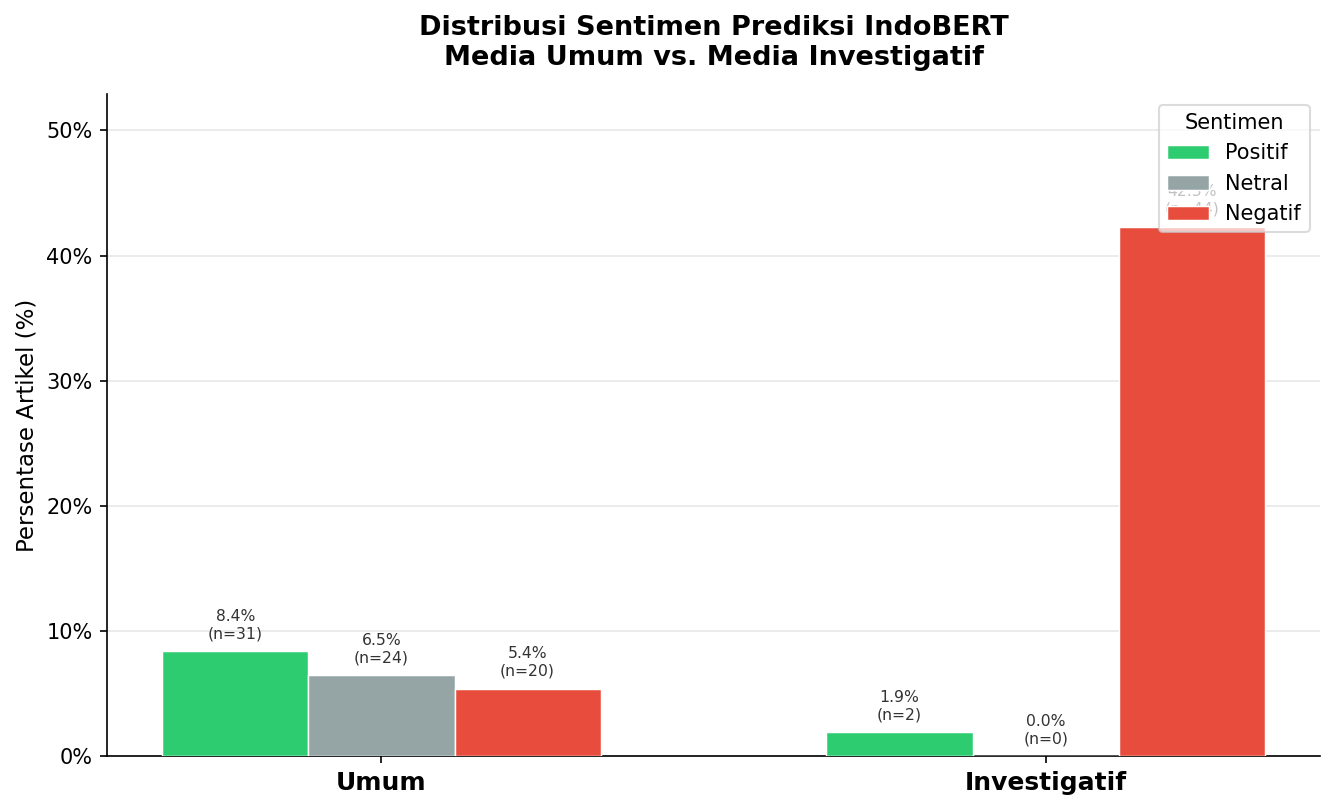

✅ Disimpan: data/models/distribusi_media_vs_sentimen.png


In [86]:
# ─── Untuk Bab 4.2 — VISUAL 1 ───────────────────────────────────────────────

SENTIMENT_ORDER = ['Positif', 'Netral', 'Negatif']
SENTIMENT_COLORS = {'Positif': '#2ECC71', 'Netral': '#95A5A6', 'Negatif': '#E74C3C'}
MEDIA_LABELS = ['Umum', 'Investigatif']

# Hitung distribusi persentase
dist_data = []
for media in MEDIA_LABELS:
    subset = df[df['Kategori_Media'] == media]['pred_sentiment']
    total = len(subset)
    for sent in SENTIMENT_ORDER:
        count = (subset == sent).sum()
        pct = count / total * 100 if total > 0 else 0
        dist_data.append({'Media': media, 'Sentimen': sent, 'Persen': pct, 'Jumlah': count})

df_dist = pd.DataFrame(dist_data)

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(MEDIA_LABELS))
width = 0.22
offsets = [-width, 0, width]

for i, sent in enumerate(SENTIMENT_ORDER):
    vals = [df_dist[(df_dist['Media'] == m) & (df_dist['Sentimen'] == sent)]['Persen'].values[0]
            for m in MEDIA_LABELS]
    counts = [df_dist[(df_dist['Media'] == m) & (df_dist['Sentimen'] == sent)]['Jumlah'].values[0]
              for m in MEDIA_LABELS]
    bars = ax.bar(x + offsets[i], vals, width=width,
                  color=SENTIMENT_COLORS[sent], label=sent, zorder=3,
                  edgecolor='white', linewidth=0.7)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{bar.get_height():.1f}%\n(n={cnt})',
                ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(MEDIA_LABELS, fontsize=12, fontweight='bold')
ax.set_ylabel('Persentase Artikel (%)', fontsize=11)
ax.set_title('Distribusi Sentimen Prediksi IndoBERT\nMedia Umum vs. Media Investigatif',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylim(0, df_dist['Persen'].max() * 1.25)
ax.legend(title='Sentimen', fontsize=10, title_fontsize=10,
          framealpha=0.7, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
SAVE_V1 = os.path.join(OUTPUT_DIR, 'distribusi_media_vs_sentimen.png')
plt.savefig(SAVE_V1, dpi=180, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {SAVE_V1}')

---
## Ringkasan Output

In [87]:
print('=' * 60)
print('         RINGKASAN OUTPUT — ESG GREENWASHING ANALYSIS')
print('=' * 60)

print(f"\n📊 VISUAL 1  → {SAVE_V1}")
print(f"   Distribusi sentimen (%) Umum vs Investigatif")

print(f"\n📊 VISUAL 2  → {SAVE_V2} (Generated in Step 2)")
print(f"   Top 10 SDS Greenwashing (horizontal bar)")

print(f"\n📋 TABEL 1   → {SAVE_T1} (Generated in Step 2)")
print(f"   {len(df_sds_export)} perusahaan | kolom: Perusahaan, Mean_Umum, Mean_Investigatif, SDS, Frekuensi")

print(f"\n📋 TABEL 2   → {SAVE_T2} (Generated in Step 3)")
print(f"   Top 10 puffery words untuk {df_puffery['Perusahaan'].nunique()} perusahaan SDS tertinggi")

print('\n' + '=' * 60)
print('✅ Pipeline selesai. Semua output siap untuk Bab 4.')

         RINGKASAN OUTPUT — ESG GREENWASHING ANALYSIS

📊 VISUAL 1  → data/models/distribusi_media_vs_sentimen.png
   Distribusi sentimen (%) Umum vs Investigatif

📊 VISUAL 2  → data/models/top_10_sds_greenwashing.png (Generated in Step 2)
   Top 10 SDS Greenwashing (horizontal bar)

📋 TABEL 1   → data/models/SDS_Greenwashing_Result.csv (Generated in Step 2)
   3 perusahaan | kolom: Perusahaan, Mean_Umum, Mean_Investigatif, SDS, Frekuensi

📋 TABEL 2   → data/models/Puffery_Words_Top5.csv (Generated in Step 3)
   Top 10 puffery words untuk 3 perusahaan SDS tertinggi

✅ Pipeline selesai. Semua output siap untuk Bab 4.
